# Obj to spikes

In [2]:
from utils import load_it_data, evaluation_metrics

it_data_dir = '.'
stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(it_data_dir)

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

class ObjectsDataset(Dataset):
    def __init__(self, objects, spikes, device):
        self.objects = torch.tensor(objects, dtype=torch.long, device=device)
        self.spikes = torch.tensor(spikes, dtype=torch.float32, device=device)

    def __len__(self):
        return len(self.objects)

    def __getitem__(self, idx):
        obj = self.objects[idx]
        spike = self.spikes[idx]
        return obj, spike

    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

label_encoder = LabelEncoder()
objects_train_encoded = label_encoder.fit_transform(objects_train)
objects_val_encoded = label_encoder.fit_transform(objects_val)
num_classes = len(label_encoder.classes_)

train_dataset = ObjectsDataset(objects_train_encoded, spikes_train, device)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_inputs = torch.tensor(objects_val_encoded, dtype=torch.long, device=device)
val_targets = torch.tensor(spikes_val, dtype=torch.float32, device=device)

# Display 1st batch shape
for objects_batch, spikes_batch in train_loader:
    print(f"Spikes batch shape: {objects_batch.shape}")
    print(f"Spikes batch shape: {spikes_batch.shape}")
    print(f"Num classes: {num_classes}")
    break

Using device: cpu
Spikes batch shape: torch.Size([8])
Spikes batch shape: torch.Size([8, 168])
Num classes: 64


In [11]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

def calculate_metrics(predictions, targets):
    """
    Calcule et retourne des métriques d'évaluation pour les prédictions de spikes.
    
    Args:
        predictions: np.ndarray de forme [N, 168] - les prédictions du modèle
        targets: np.ndarray de forme [N, 168] - les valeurs cibles réelles
    
    Returns:
        dict: Dictionnaire contenant différentes métriques
    """
    n_neurons = predictions.shape[1]
    
    # Initialisation des arrays pour stocker les métriques par neurone
    correlations = np.zeros(n_neurons)
    explained_variances = np.zeros(n_neurons)
    mses = np.zeros(n_neurons)
    
    # Calcul des métriques pour chaque neurone
    for i in range(n_neurons):
        y_true = targets[:, i]
        y_pred = predictions[:, i]
        
        # Corrélation de Pearson
        corr, _ = pearsonr(y_true, y_pred)
        correlations[i] = corr
        
        # Variance expliquée (R²)
        y_true_mean = np.mean(y_true)
        ss_total = np.sum((y_true - y_true_mean) ** 2)
        ss_residual = np.sum((y_true - y_pred) ** 2)
        r2 = 1 - (ss_residual / ss_total) if ss_total != 0 else 0
        explained_variances[i] = max(0, r2)  # R² peut être négatif, le limiter à 0
        
        # MSE
        mses[i] = np.mean((y_true - y_pred) ** 2)
    
    # Calcul des statistiques globales
    metrics = {
        'correlation_mean': np.mean(correlations),
        'correlation_median': np.median(correlations),
        'explained_variance_mean': np.mean(explained_variances),
        'explained_variance_median': np.median(explained_variances),
        'mse_mean': np.mean(mses),
        'correlations': correlations,
        'explained_variances': explained_variances,
        'mses': mses
    }
    
    return metrics

def plot_metrics(metrics):
    """
    Affiche les histogrammes des métriques par neurone
    
    Args:
        metrics: dict - résultat de calculate_metrics
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histogramme des corrélations
    axes[0].hist(metrics['correlations'], bins=20)
    axes[0].set_title(f"Corrélation (moyenne={metrics['correlation_mean']:.3f})")
    axes[0].set_xlabel("Corr")
    axes[0].set_ylabel("Nb of neurons")
    
    # Histogramme des variances expliquées
    axes[1].hist(metrics['explained_variances'], bins=20)
    axes[1].set_title(f"Variance expliquée (moyenne={metrics['explained_variance_mean']:.3f})")
    axes[1].set_xlabel("EV")
    axes[1].set_ylabel("Nb of neurons")
    
    # Histogramme des MSE
    axes[2].hist(metrics['mses'], bins=20)
    axes[2].set_title(f"MSE (moyenne={metrics['mse_mean']:.3f})")
    axes[2].set_xlabel("MSE")
    axes[2].set_ylabel("Nb of neurons")
    
    plt.tight_layout()
    plt.show()
    
    return fig

Epoch 1/20, Loss train: 0.1264, Loss val: 0.1185
EV: 0.1393, Corr: 0.3613
Epoch 2/20, Loss train: 0.1152, Loss val: 0.1154
EV: 0.1595, Corr: 0.3834
Epoch 3/20, Loss train: 0.1122, Loss val: 0.1148
EV: 0.1604, Corr: 0.3918
Epoch 4/20, Loss train: 0.1111, Loss val: 0.1128
EV: 0.1719, Corr: 0.4017
Epoch 5/20, Loss train: 0.1102, Loss val: 0.1132
EV: 0.1698, Corr: 0.4058
Epoch 6/20, Loss train: 0.1097, Loss val: 0.1125
EV: 0.1738, Corr: 0.4082
Epoch 7/20, Loss train: 0.1093, Loss val: 0.1129
EV: 0.1716, Corr: 0.4062
Epoch 8/20, Loss train: 0.1090, Loss val: 0.1118
EV: 0.1791, Corr: 0.4099
Epoch 9/20, Loss train: 0.1089, Loss val: 0.1129
EV: 0.1727, Corr: 0.4044
Epoch 10/20, Loss train: 0.1090, Loss val: 0.1121
EV: 0.1775, Corr: 0.4097
Epoch 11/20, Loss train: 0.1083, Loss val: 0.1127
EV: 0.1735, Corr: 0.4048
Epoch 12/20, Loss train: 0.1082, Loss val: 0.1122
EV: 0.1755, Corr: 0.4089
Epoch 13/20, Loss train: 0.1084, Loss val: 0.1123
EV: 0.1740, Corr: 0.4086
Epoch 14/20, Loss train: 0.1079, L

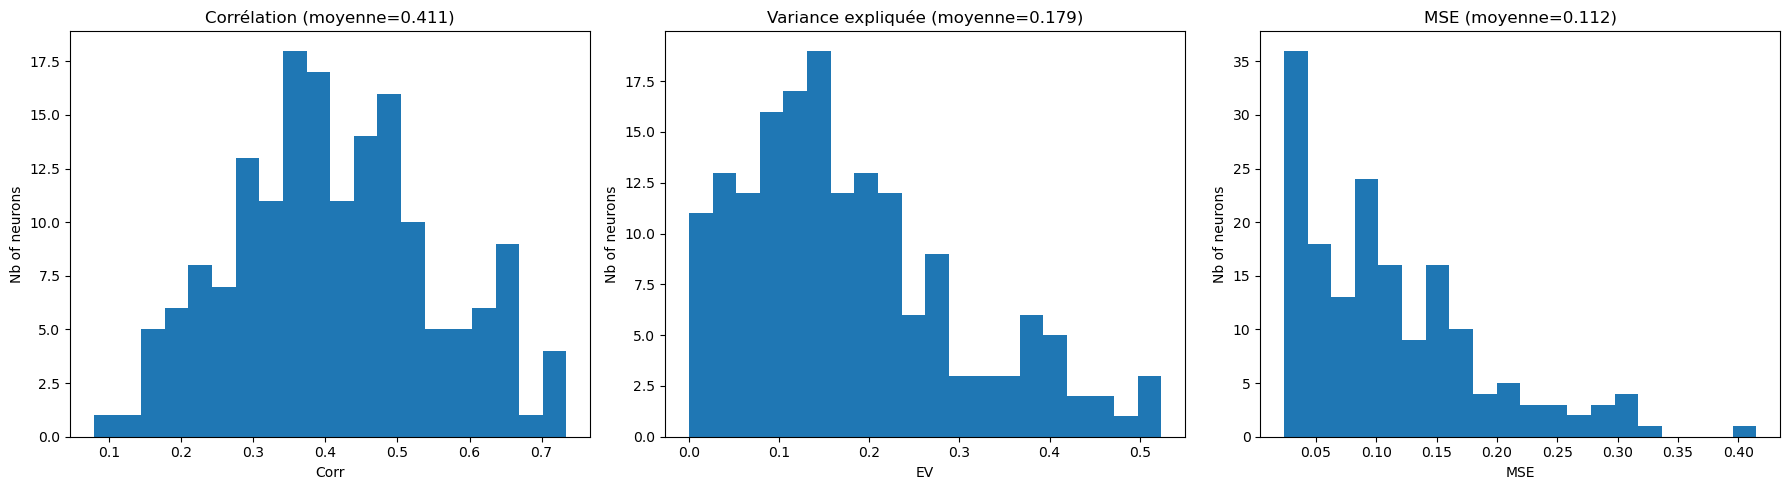

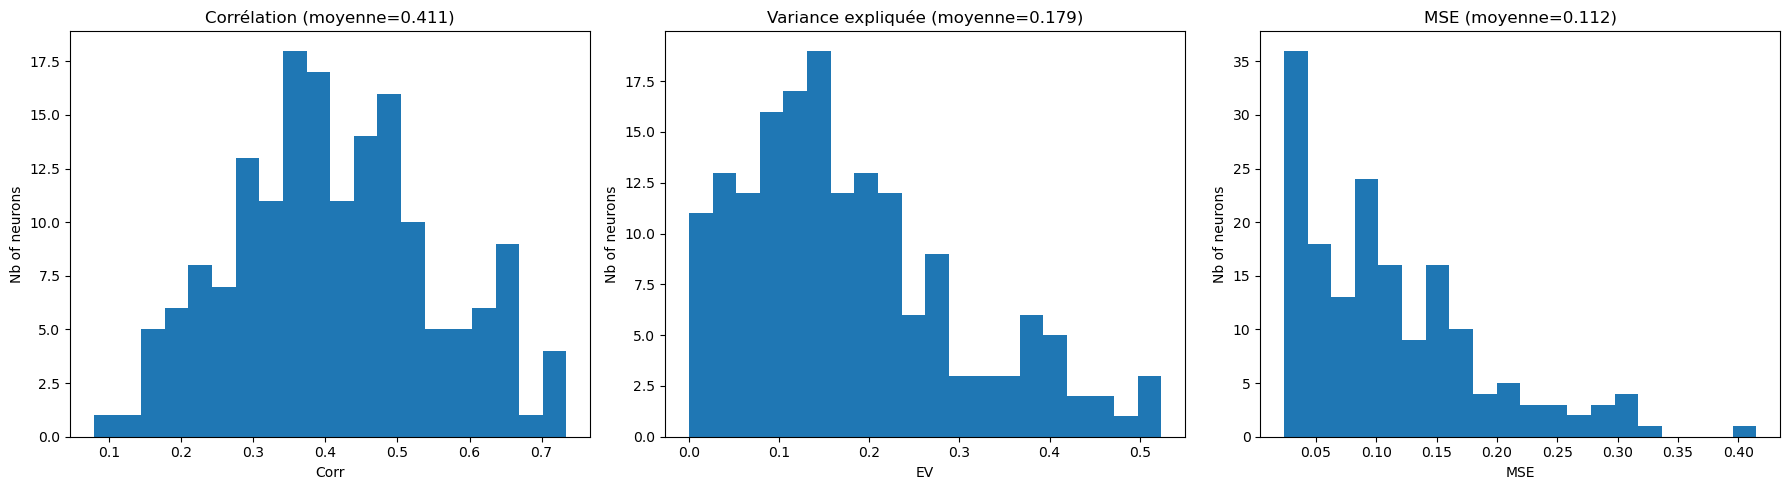

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

class ObjectToSpikesModel(nn.Module):
    def __init__(self, num_classes, embedding_dim=64, hidden_dim=128, spike_dim=168):
        super().__init__()
        self.embedding = nn.Embedding(num_classes, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, spike_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.dropout(self.relu(self.fc3(x)))
        x = self.fc4(x)
        return x

# Initialisation du modèle
model = ObjectToSpikesModel(num_classes).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Boucle d'entraînement
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for objects_batch, spikes_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(objects_batch)
        loss = criterion(outputs, spikes_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(val_inputs)
        val_loss = criterion(val_outputs, val_targets)
        
        # Calcul des métriques avec la fonction fournie
        val_metrics = calculate_metrics(val_outputs.cpu().numpy(), val_targets.cpu().numpy())
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss train: {train_loss/len(train_loader):.4f}, Loss val: {val_loss:.4f}")
    print(f"EV: {val_metrics['explained_variance_mean']:.4f}, Corr: {val_metrics['correlation_mean']:.4f}")

plot_metrics(val_metrics)